# НИС «Основы анализа данных в Python»

*Алла Тамбовцева*

## Практикум 8. Датафреймы `pandas`: группировка и агрегирование

В этом задании вам предлагается поработать с данными о заказах пиццы (источник – [Kaggle](https://www.kaggle.com/datasets/neethimohan/maven-pizza-challenge-dataset)).

В файле `orders.csv` (скачать [здесь](https://github.com/allatambov/PyDat25/blob/main/orders.csv)) хранится общая информация о заказах пиццы:

* `id`: номер заказа;
* `date`: дата заказа;
* `time`: время заказа.

В файле `order_details.csv` (скачать [здесь](https://github.com/allatambov/PyDat25/blob/main/order_details.csv)) хранится более подробная информация о заказах пиццы:

* `order_details_id`: номер записи (одной пиццы в заказе);
* `order_id`: номер заказа;
* `pizza_id`: номер пиццы, состоит из её названия (с `_` вместо пробелов) и её размера (`l/m/s/xl/xxl`, после последнего `_`);
* `quantity`: число пицц с данным номером в заказе.

Загрузите данные из файлов и сохраните их в датафреймы `orders` и `details` соответственно. 

In [1]:
import pandas as pd

orders = pd.read_csv("https://raw.githubusercontent.com/allatambov/PyDat25/refs/heads/main/orders.csv")
details = pd.read_csv("https://raw.githubusercontent.com/allatambov/PyDat25/refs/heads/main/order_details.csv")

In [2]:
orders.head()

,id,date,time
0,1,2015-01-01,11:38:36
1,2,2015-01-01,11:57:40
2,3,2015-01-01,12:12:28
3,4,2015-01-01,12:16:31
4,5,2015-01-01,12:21:30


In [3]:
details.head(10)

,order_details_id,order_id,pizza_id,quantity
0,1,1,hawaiian_m,1
1,2,2,classic_dlx_m,1
2,3,2,five_cheese_l,1
3,4,2,ital_supr_l,1
4,5,2,mexicana_m,1
5,6,2,thai_ckn_l,1
6,7,3,ital_supr_m,1
7,8,3,prsc_argla_l,1
8,9,4,ital_supr_m,1
9,10,5,ital_supr_m,1


### Задача 1

Для каждого заказа в датасете `details` найдите время и дату заказа. Назовите объединённый датафрейм `full`. 

a. Определите число заказов (`order_id`).

b. Выберите строку с индексом 234. Сколько пицц в заказе, часть которого описана в выбранной строке?

In [4]:
# объединяем по id заказа,
# в левом датафрейме details он называется order_id,
# в правом датафрейме orders он называется id

full = details.merge(orders, how = "left", 
                     left_on = "order_id", 
                     right_on = "id")

# удаляем столбец id, он остался после объединения
# и дублирует order_id

full.drop(columns = ["id"], inplace = True)
full.head()

,order_details_id,order_id,pizza_id,quantity,date,time
0,1,1,hawaiian_m,1,2015-01-01,11:38:36
1,2,2,classic_dlx_m,1,2015-01-01,11:57:40
2,3,2,five_cheese_l,1,2015-01-01,11:57:40
3,4,2,ital_supr_l,1,2015-01-01,11:57:40
4,5,2,mexicana_m,1,2015-01-01,11:57:40


In [5]:
# a
# определяем уникальные значения и считаем их число

print(full["order_id"].unique().size)
print(len(full["order_id"].unique()))

21350
21350


In [6]:
# b
# выбираем строку по индексу 234

full.iloc[234, :]

order_details_id           235
order_id                   101
pizza_id            cali_ckn_l
quantity                     1
date                2015-01-02
time                  17:51:33
Name: 234, dtype: object

In [7]:
# забираем id заказа, выбираем строки для этого id

i = full.iloc[234, :]["order_id"]
full[full["order_id"] == i]

,order_details_id,order_id,pizza_id,quantity,date,time
234,235,101,cali_ckn_l,1,2015-01-02,17:51:33
235,236,101,pepperoni_l,1,2015-01-02,17:51:33
236,237,101,soppressata_l,1,2015-01-02,17:51:33
237,238,101,spicy_ital_m,1,2015-01-02,17:51:33


In [8]:
# забираем quantity и суммируем

full[full["order_id"] == i]["quantity"].sum()

4

**ОТВЕТЫ: a. 21350; b. 4**

### Задача 2

Выведите общее число пицц в заказах, сделанных между 16:00:00 и 18:59:59 16 декабря.

In [9]:
# склеиваем два столбца в один по пробелу, 
# чтобы сразу была дата и время заказа

full["datetime"] = full["date"].str.cat(full["time"], sep = " ")
full.head()

,order_details_id,order_id,pizza_id,quantity,date,time,datetime
0,1,1,hawaiian_m,1,2015-01-01,11:38:36,2015-01-01 11:38:36
1,2,2,classic_dlx_m,1,2015-01-01,11:57:40,2015-01-01 11:57:40
2,3,2,five_cheese_l,1,2015-01-01,11:57:40,2015-01-01 11:57:40
3,4,2,ital_supr_l,1,2015-01-01,11:57:40,2015-01-01 11:57:40
4,5,2,mexicana_m,1,2015-01-01,11:57:40,2015-01-01 11:57:40


In [10]:
# меняем тип столбца на дата-время

full["datetime"] = pd.to_datetime(full["datetime"])

In [11]:
# извлекаем из даты месяц, день, час

full["month"] = full["datetime"].dt.month
full["day"] = full["datetime"].dt.day
full["hour"] = full["datetime"].dt.hour
full.head()

,order_details_id,order_id,pizza_id,quantity,date,time,datetime,month,day,hour
0,1,1,hawaiian_m,1,2015-01-01,11:38:36,2015-01-01 11:38:36,1,1,11
1,2,2,classic_dlx_m,1,2015-01-01,11:57:40,2015-01-01 11:57:40,1,1,11
2,3,2,five_cheese_l,1,2015-01-01,11:57:40,2015-01-01 11:57:40,1,1,11
3,4,2,ital_supr_l,1,2015-01-01,11:57:40,2015-01-01 11:57:40,1,1,11
4,5,2,mexicana_m,1,2015-01-01,11:57:40,2015-01-01 11:57:40,1,1,11


In [12]:
# ищем заказы за 16 декабря между 16 и 18 включительно

chosen = full[(full["day"] == 16) & 
     (full["month"] == 12) & 
     (full["hour"].between(16, 18))]

# считаем общее = суммарное число пицц

chosen["quantity"].sum()

45

**ОТВЕТ: 45**

### Задача 3

Выведите максимальное общее число пицц в заказе. Какого вида пицц (`pizza_id`) в этом заказе больше всего?

In [13]:
# в заказе – группируем по id заказа
# выбираем quantity и суммируем
# в tab общее число пицц в каждом заказе

tab = full.groupby("order_id")["quantity"].sum()
tab.head()

order_id
1    1
2    5
3    2
4    1
5    1
Name: quantity, dtype: int64

In [14]:
# считаем максимум

print(tab.max())

28


In [15]:
# находим индекс строки в tab,
# где достигается максимум

i = tab.idxmax()
print(i)

18845


In [16]:
# выбираем строки, соответствующие этому заказу

dat = full[full["order_id"] == i]
dat

,order_details_id,order_id,pizza_id,quantity,date,time,datetime,month,day,hour
42846,42847,18845,bbq_ckn_m,3,2015-11-18,12:25:12,2015-11-18 12:25:12,11,18,12
42847,42848,18845,big_meat_s,2,2015-11-18,12:25:12,2015-11-18 12:25:12,11,18,12
42848,42849,18845,calabrese_m,1,2015-11-18,12:25:12,2015-11-18 12:25:12,11,18,12
42849,42850,18845,ckn_alfredo_m,1,2015-11-18,12:25:12,2015-11-18 12:25:12,11,18,12
42850,42851,18845,ckn_pesto_s,1,2015-11-18,12:25:12,2015-11-18 12:25:12,11,18,12
42851,42852,18845,classic_dlx_m,1,2015-11-18,12:25:12,2015-11-18 12:25:12,11,18,12
42852,42853,18845,classic_dlx_s,1,2015-11-18,12:25:12,2015-11-18 12:25:12,11,18,12
42853,42854,18845,four_cheese_l,1,2015-11-18,12:25:12,2015-11-18 12:25:12,11,18,12
42854,42855,18845,green_garden_m,1,2015-11-18,12:25:12,2015-11-18 12:25:12,11,18,12
42855,42856,18845,hawaiian_l,1,2015-11-18,12:25:12,2015-11-18 12:25:12,11,18,12


In [17]:
# в таблице выше видно, что максимальное quantity = 3
# у bbq_ckn_m, но рассмотрим более общий случай,
# снова найдем id строки, в которой достигается максимум,
# а затем выберем из этой строки ячейку с pizza_id

j = dat["quantity"].idxmax()
print(dat.loc[j, "pizza_id"])

bbq_ckn_m


**ОТВЕТЫ: максимум 28; в таком заказе больше всего пицц типа `bbq_ckn_m` (их 3)**

### Задача 4

Выведите среднее, медианное и максимальное общее число пицц в заказе (`quantity`).

In [19]:
# ключевое слово – общее число пицц в заказе, поэтому
# группируем по id заказа и суммируем столбец quantity
# в каждой группе

tab

order_id
1        1
2        5
3        2
4        1
5        1
        ..
21346    4
21347    4
21348    3
21349    1
21350    1
Name: quantity, Length: 21350, dtype: int64

In [20]:
print(tab.mean())
print(tab.median())
print(tab.max())

2.321967213114754
2.0
28


**ОТВЕТЫ: 2.32, 2.0, 28**

### Задача 5

Определите размах числа пицц в каждом заказе. Чему равен максимальный размах числа пицц в каждом заказе? Сколько таких заказов?

In [21]:
# минимум по группе
full.groupby("order_id")["quantity"].min()

order_id
1        1
2        1
3        1
4        1
5        1
        ..
21346    1
21347    1
21348    1
21349    1
21350    1
Name: quantity, Length: 21350, dtype: int64

In [22]:
# максимум по группе
full.groupby("order_id")["quantity"].max()

order_id
1        1
2        1
3        1
4        1
5        1
        ..
21346    1
21347    1
21348    1
21349    1
21350    1
Name: quantity, Length: 21350, dtype: int64

In [23]:
# минимум и максимум сразу – списком внутри .agg()
full.groupby("order_id")["quantity"].agg(["min", "max"])

,min,max
order_id,,
1,1,1
2,1,1
3,1,1
4,1,1
5,1,1
...,...,...
21346,1,1
21347,1,1
21348,1,1


In [24]:
# внутри .agg() можем указать функцию,
# пишем lambda-функцию для размаха,
# max - min

tab_range = full.groupby("order_id")["quantity"].agg(lambda x : x.max() - x.min())
tab_range

order_id
1        0
2        0
3        0
4        0
5        0
        ..
21346    0
21347    0
21348    0
21349    0
21350    0
Name: quantity, Length: 21350, dtype: int64

In [25]:
# максимум 3, значит, минимальное число пицц в заказе 1,
# а максимальное – 4

tab_range.max()

3

In [26]:
# выбираем строки, где размах максимальный,
# таких заказов 3

tab_range[tab_range == tab_range.max()]

order_id
5264     3
8286     3
15674    3
Name: quantity, dtype: int64

**ОТВЕТ: максимальный размах 3; таких заказов 3**

### Задача 6

Добавьте в объединённый датафрейм:

* столбец `pizza_size` с размером пиццы заглавными буквами (значения из `pizza_id` после последнего `_`);
* столбец `pizza_type` с названием пиццы без указания её размера (значения из `pizza_id` до `_m`, `_l` и проч).

Примеры значений для некоторых заказов:

* название `hawaiian` и размер `M`;
* название `classic_dlx` и размер `M`;
* название `five_cheese` и размер `L`.

a. Пиццы какого типа заказывают чаще всего? Укажите число таких пицц.

b. Пиццы какого размера заказывают чаще всего? Укажите процент таких пицц.

c. Постройте столбиковую (`plot.bar`) и круговую диаграмму (`plot.pie`) для размера пицц. 

In [27]:
# разбиваем строки в pizza_id по _, забираем последний элемент,
# пишем его заглавными буквами

full["pizza_size"] = full["pizza_id"].apply(lambda x: x.split("_")[-1].upper())
full.head()

,order_details_id,order_id,pizza_id,quantity,date,time,datetime,month,day,hour,pizza_size
0,1,1,hawaiian_m,1,2015-01-01,11:38:36,2015-01-01 11:38:36,1,1,11,M
1,2,2,classic_dlx_m,1,2015-01-01,11:57:40,2015-01-01 11:57:40,1,1,11,M
2,3,2,five_cheese_l,1,2015-01-01,11:57:40,2015-01-01 11:57:40,1,1,11,L
3,4,2,ital_supr_l,1,2015-01-01,11:57:40,2015-01-01 11:57:40,1,1,11,L
4,5,2,mexicana_m,1,2015-01-01,11:57:40,2015-01-01 11:57:40,1,1,11,M


In [28]:
# разбиваем строки в pizza_id по _, забираем все до последнего элемента,
# склеиваем выбранные элементы обратно через _

full["pizza_type"] = full["pizza_id"].apply(lambda x: "_".join(x.split("_")[0:-1]))
full.head()

,order_details_id,order_id,pizza_id,quantity,date,time,datetime,month,day,hour,pizza_size,pizza_type
0,1,1,hawaiian_m,1,2015-01-01,11:38:36,2015-01-01 11:38:36,1,1,11,M,hawaiian
1,2,2,classic_dlx_m,1,2015-01-01,11:57:40,2015-01-01 11:57:40,1,1,11,M,classic_dlx
2,3,2,five_cheese_l,1,2015-01-01,11:57:40,2015-01-01 11:57:40,1,1,11,L,five_cheese
3,4,2,ital_supr_l,1,2015-01-01,11:57:40,2015-01-01 11:57:40,1,1,11,L,ital_supr
4,5,2,mexicana_m,1,2015-01-01,11:57:40,2015-01-01 11:57:40,1,1,11,M,mexicana


In [29]:
# a
# выводим таблицу частот для pizza_type

full["pizza_type"].value_counts()

classic_dlx     2416
bbq_ckn         2372
hawaiian        2370
pepperoni       2369
thai_ckn        2315
cali_ckn        2302
sicilian        1887
spicy_ital      1887
southw_ckn      1885
four_cheese     1850
ital_supr       1849
big_meat        1811
veggie_veg      1510
mexicana        1456
napolitana      1451
spinach_fet     1432
prsc_argla      1428
peppr_salami    1422
ital_cpcllo     1414
the_greek       1406
five_cheese     1359
pep_msh_pep     1342
green_garden     987
ckn_alfredo      980
ital_veggie      975
ckn_pesto        961
spin_pesto       957
soppressata      957
spinach_supr     940
calabrese        927
mediterraneo     923
brie_carre       480
Name: pizza_type, dtype: int64

In [30]:
# b
# выводим таблицу частот для pizza_size,
# normalize = True – в долях

full["pizza_size"].value_counts(normalize = True)

L      0.381037
M      0.316434
S      0.290765
XL     0.011189
XXL    0.000576
Name: pizza_size, dtype: float64

In [31]:
# нужны проценты – домножаем на 100

full["pizza_size"].value_counts(normalize = True) * 100

L      38.103661
M      31.643357
S      29.076512
XL      1.118881
XXL     0.057589
Name: pizza_size, dtype: float64

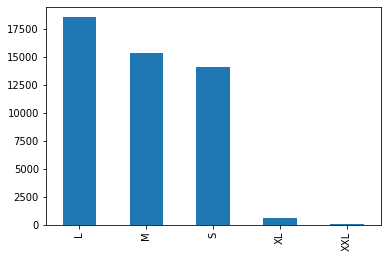

In [32]:
# к таблице частот применяем plot.bar()

full["pizza_size"].value_counts().plot.bar();

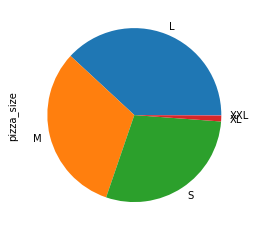

In [33]:
# к таблице частот применяем plot.pie()

full["pizza_size"].value_counts().plot.pie();

**ОТВЕТ: a. `classic_dlx`, их 2416; b. `L`, их 38.10%**

### Задача 7

Добавьте бинарный столбец `weekend`, где значение 1 соответствует выходным дням (суббота, воскресенье), а значение 0 – будним дням.

Сгруппируйте заказанные пиццы по типу дня. Определите, какую пиццу (`pizza_type`) чаще всего заказывают в будни и выходные. 

In [34]:
# если извлечем номер день недели через dt.weekday,
# субботе и воскресенью соответствуют номера 5 и 6,
# пишем условие, которое на 5-6 выдает True, на остальное – False

full["datetime"].dt.weekday > 4

0        False
1        False
2        False
3        False
4        False
         ...  
48615    False
48616    False
48617    False
48618    False
48619    False
Name: datetime, Length: 48620, dtype: bool

In [35]:
# переделываем в integer

full["weekend"] = (full["datetime"].dt.weekday > 4).astype(int)
full.head()

,order_details_id,order_id,pizza_id,quantity,date,time,datetime,month,day,hour,pizza_size,pizza_type,weekend
0,1,1,hawaiian_m,1,2015-01-01,11:38:36,2015-01-01 11:38:36,1,1,11,M,hawaiian,0
1,2,2,classic_dlx_m,1,2015-01-01,11:57:40,2015-01-01 11:57:40,1,1,11,M,classic_dlx,0
2,3,2,five_cheese_l,1,2015-01-01,11:57:40,2015-01-01 11:57:40,1,1,11,L,five_cheese,0
3,4,2,ital_supr_l,1,2015-01-01,11:57:40,2015-01-01 11:57:40,1,1,11,L,ital_supr,0
4,5,2,mexicana_m,1,2015-01-01,11:57:40,2015-01-01 11:57:40,1,1,11,M,mexicana,0


> Отступление: мода считается через метод `.mode()`, однако из-за того, что мод теоретически может быть несколько (в отличие от среднего, медианы и подобного – эти характеристики всегда в виде одного числа), результат возвращается в виде столбца `pandas Series`:

In [36]:
# одна мода – одна строка с индексом 0

full["pizza_type"].mode()

0    classic_dlx
dtype: object

> Чтобы забрать моду в виде отдельного значения, его надо выбрать по индексу (если мод несколько – два самых частых значения встречаются одинаковое число раз – выберем первую):

In [37]:
full["pizza_type"].mode()[0]

'classic_dlx'

> Эта особенность вызывает дополнительные сложности – из-за неоднозначного результата, метод `.mode()` не работает с группировкой:

In [40]:
# среднее число заказов в будни и выходные – можно,
# максимальное число заказов в будни и выходные – тоже можно,
# суммарное число заказов в будни и выходные – пожалуйста

print(full.groupby("weekend")["quantity"].mean())
print(full.groupby("weekend")["quantity"].max())
print(full.groupby("weekend")["quantity"].sum())

weekend
0    1.019747
1    1.019289
Name: quantity, dtype: float64
weekend
0    4
1    4
Name: quantity, dtype: int64
weekend
0    36046
1    13528
Name: quantity, dtype: int64


In [41]:
# а вот моду для каждой группы – нельзя

print(full.groupby("weekend")["pizza_type"].mode())

AttributeError: 'SeriesGroupBy' object has no attribute 'mode'

> Чтобы обойти проблему, поступим как с размахом – напишем свою функцию в `.agg()` для вычисления моды по столбцу внутри группы:

In [42]:
# считаем моду и забираем первый результат с индексом 0

full.groupby("weekend")["pizza_type"].apply(lambda x: x.mode()[0])

weekend
0    classic_dlx
1      pepperoni
Name: pizza_type, dtype: object

**ОТВЕТ: в будни чаще всего заказывают `classic_dlx`, в выходные – `pepperoni`.**

### Задача 8

Представить, что в подобного рода данных есть пропущенные значения, довольно сложно – вряд ли можно сделать заказ, не указав название пиццы или количество пицц. Поэтому представим, что наш объединённый датафрейм атаковали хакеры, которые не любят пиццу и число 13 – они удалили информацию о типе пицц `pizza_type` во всех строках, индексы которых делятся на 13:

In [43]:
# имитируем действия воображаемых хакеров,
# в горячую пору дедлайнов можно и такое вообразить

inds = full.index 
vals = inds[inds % 13 == 0]
full.loc[vals, "pizza_type"] = None

Заполните пропуски в `pizza_type` таким образом, чтобы на их месте был самый популярный тип пиццы в будни и выходные.

In [44]:
# как и в прошлом практикуме, группируем (по weekend),
# выбираем pizza_type, и в каждой группе изменяем 
# его через .transform(), заполняя пропуски модой,
# используя fillna()

full["pizza_type"] = full.groupby("weekend")["pizza_type"].transform(lambda x: x.fillna(x.mode()[0]))

In [45]:
# пропусков нет, пропуски в pizza_type 
# заполнились classic_dlx, если заказ в будни (weekend = 0), 
# заполнились pepperoni, если заказ в выходные (weekend = 1), 

full["pizza_type"].isna().sum()

0